In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [9]:
train_path = r"C:\Users\HP 15\Downloads\archive (13)\animals"

test_path = r"C:\Users\HP 15\Downloads\archive (13)\animals"

In [10]:
import os

print(os.path.exists(train_path))
print(os.path.exists(test_path))

True
True


In [11]:
training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [12]:
test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.


In [13]:
model = Sequential()

In [14]:
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [15]:
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [16]:
model.add(Flatten())

In [17]:
model.add(
    Dense(
        128,
        activation='relu'
    )
)

In [18]:
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    training_set,
    epochs=5,
    validation_data=test_set
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5040 - loss: 0.8805 - val_accuracy: 0.5000 - val_loss: 0.6704
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6900 - loss: 0.5827 - val_accuracy: 0.7990 - val_loss: 0.4500
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8250 - loss: 0.4088 - val_accuracy: 0.8190 - val_loss: 0.4385
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 911ms/step - accuracy: 0.8310 - loss: 0.3886 - val_accuracy: 0.9090 - val_loss: 0.2559
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 962ms/step - accuracy: 0.9040 - loss: 0.2586 - val_accuracy: 0.9410 - val_loss: 0.1862


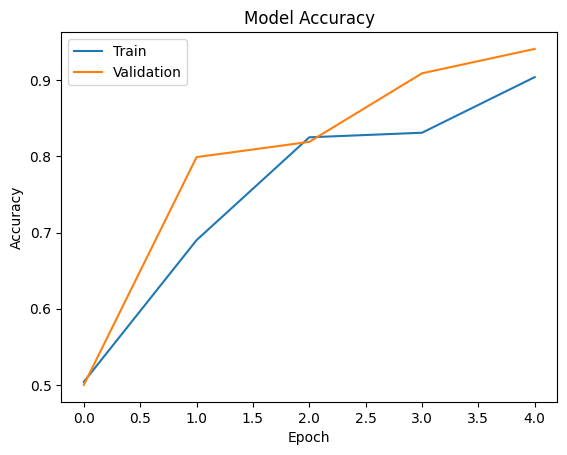

In [23]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

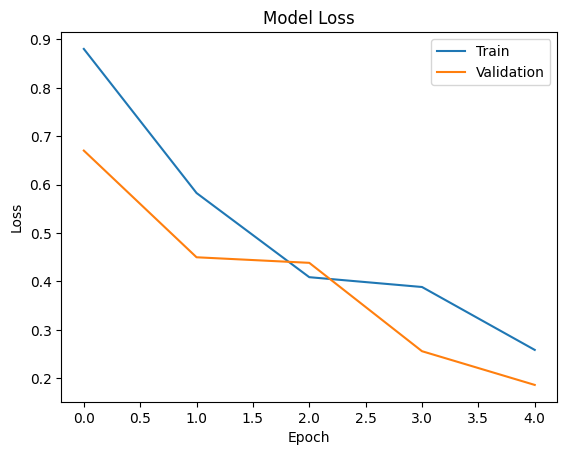

In [24]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [25]:
model.save("cnn_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
